# EPC01 Forca bruta

Implemente três algoritmos para identificar se todos os elementos de uma lista são únicos. Um dos algoritmos deve ser baseado no método força bruta, os demais algoritmos devem ter complexidade n*log(n) e n. Todos os algoritmos devem ser implementados em python (sem utilizar nenhuma biblioteca externa). Eles devem receber como parâmetro uma lista de elementos e devem retornar verdadeiro quando todos os elementos da lista forem únicos, e falso, caso contrário. 

Você deve implementar também um código que gere um gráfico comparando o desempenho dos três algoritmos utilizando listas com diferentes tamanhos.

Você deve enviar o código dos três algoritmos e do gráfico em um arquivo único no formato .ipypnb. Ao enviar o seu EPC, por favor, nomeie o seu arquivo para: EPC01-SeuNome.ipynb

In [1]:
from typing import List

In [2]:
# Unique Elements brute force with complexity theta(n²)
def unique_elements_theta_squared(L:List):
  for i in range(len(L) - 1):
    for j in range(i+1, len(L)):
      if L[i] == L[j]:
        return False
  return True

list_elements = [1, 4, 3, 4, 5]
print(f"resultado: {unique_elements_theta_squared(list_elements)}")

resultado: False


In [3]:
# Elementos únicos com nlon(g)
def unique_elements_nlog(L:List):
    L.sort()

    for i in range(len(L) - 1):
        if L[i] == L[i+1]:
            return False
    return True

In [4]:
def unique_elements_n(L:List):
    is_unique = set()

    for i in range(len(L)):
        if L[i] in is_unique:
            return False
        else:
            is_unique.add(L[i])
    return True 

In [5]:
unique_elements = [1, 7, 3, 4, 5]
nounique_elements = [1, 2, 3, 5, 5]

print(f"resultado theta(n²) com unique: {unique_elements_theta_squared(unique_elements)}")
print(f"resultado theta(n²) com nounique_elements: {unique_elements_theta_squared(nounique_elements)}")

print(f"resultado n*log(n) com unique: {unique_elements_nlog(unique_elements)}")
print(f"resultado n*log(n) com nounique_elements: {unique_elements_nlog(nounique_elements)}")

print(f"resultado n com unique: {unique_elements_n(unique_elements)}")
print(f"resultado n com nounique_elements: {unique_elements_n(nounique_elements)}")

resultado theta(n²) com unique: True
resultado theta(n²) com nounique_elements: False
resultado n*log(n) com unique: True
resultado n*log(n) com nounique_elements: False
resultado n com unique: True
resultado n com nounique_elements: False


In [6]:
# Coleta de dados para o experimento
import time
from numpy import random
DOMAIN = 1000000000 #1B
def avgTime(L,func,rounds):
  random.seed(17)
  s = 0
  for i in range(rounds):
    start = time.time()
    func(L)
    end = time.time()
    s += end-start
  return s/rounds

#defines the algorithms to be processed
algorithms = [unique_elements_theta_squared, unique_elements_nlog, unique_elements_n]

#defines the number of times each algorithm will be processed to find the average time
num_rounds = 2

##sizes 1M, 5M, 10M, 15M, 20M
sizes = [1000000, 5000000,10000000,15000000,20000000]
mapSizeToTime = dict()
for i in range(5):
  print(f"Starting round {i+1}")

  #create a list with random numbers
  L=random.randint(DOMAIN, size=sizes[i])

  ##Map list size to algorithm average time
  for algorithm in algorithms:
    mapSizeToTime[f"{algorithm.__name__ }##{sizes[i]}"] = avgTime(L, algorithm, num_rounds)

print(f"Finish data collection")

Starting round 1
Starting round 2
Starting round 3
Starting round 4
Starting round 5
Finish data collection


In [7]:
#formata os dados do experimento para exibir
import pandas as pd
df = pd.DataFrame.from_dict(mapSizeToTime, orient='index',columns=['Time'])
df['Algorithm'] = [i.split("##")[0] for i in df.index]
df['Size'] = [int(i.split("##")[1]) for i in df.index]
df

,Time,Algorithm,Size
unique_elements_theta_squared##1000000,62.967320,unique_elements_theta_squared,1000000
unique_elements_nlog##1000000,0.015719,unique_elements_nlog,1000000
unique_elements_n##1000000,0.000115,unique_elements_n,1000000
unique_elements_theta_squared##5000000,101.560993,unique_elements_theta_squared,5000000
unique_elements_nlog##5000000,0.085561,unique_elements_nlog,5000000
unique_elements_n##5000000,0.000058,unique_elements_n,5000000
unique_elements_theta_squared##10000000,11.400239,unique_elements_theta_squared,10000000
unique_elements_nlog##10000000,0.178570,unique_elements_nlog,10000000
unique_elements_n##10000000,0.000006,unique_elements_n,10000000
unique_elements_theta_squared##15000000,16.426537,unique_elements_theta_squared,15000000


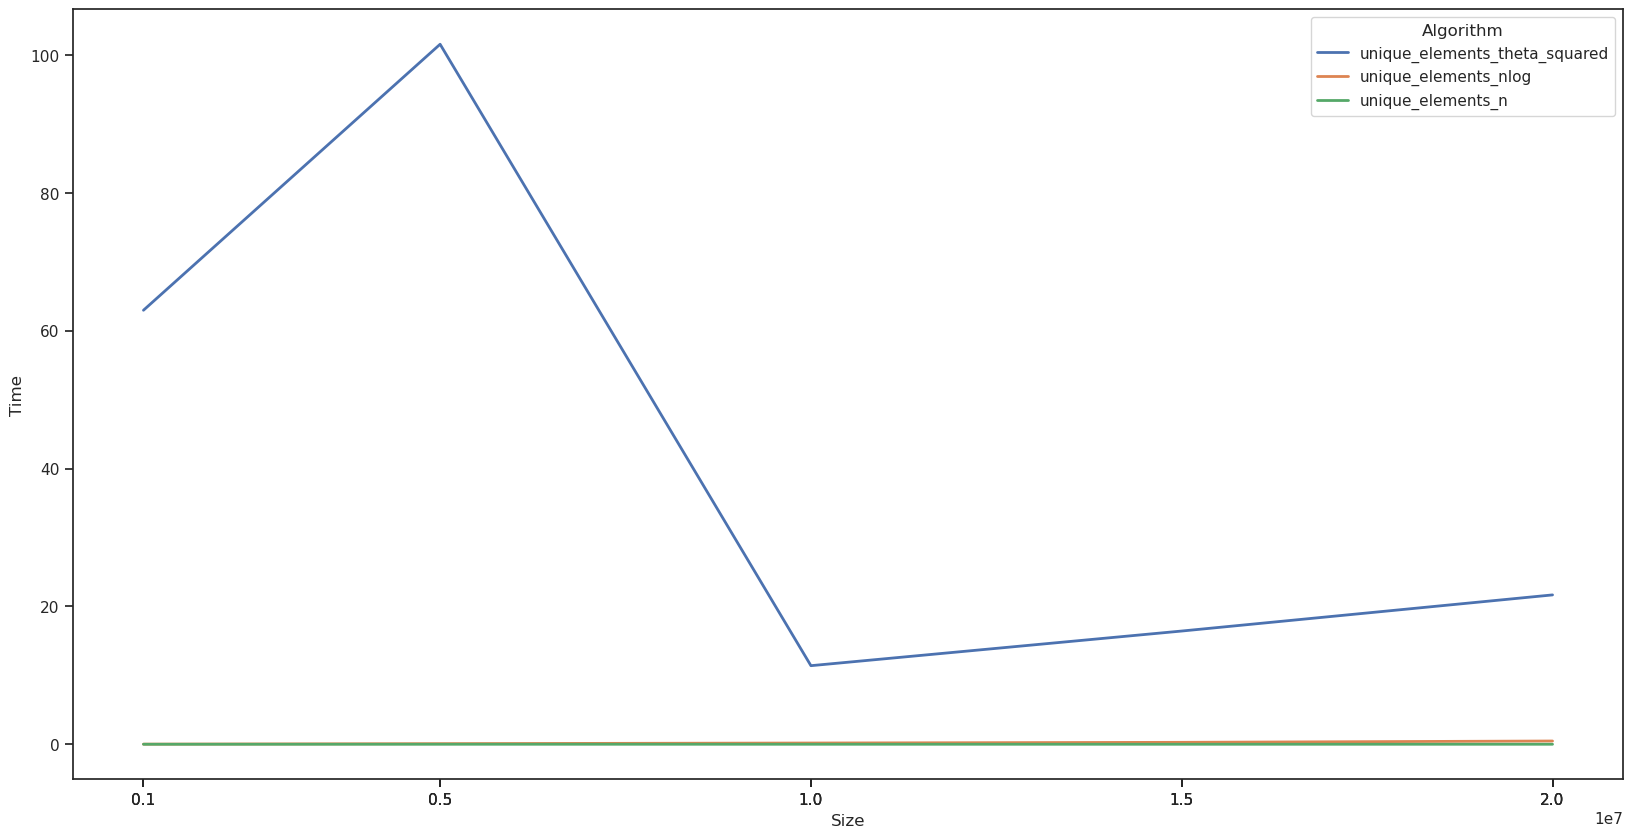

<Figure size 2000x1000 with 0 Axes>

In [8]:
#resultado do experimento
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

##Defines font size and line width
sns.set(font_scale=1, style="ticks", rc={"lines.linewidth": 2})

##Defines plot size
plt.rcParams['figure.figsize'] = [20, 10]

g = sns.lineplot(x='Size', y='Time', hue='Algorithm', data=df)
#g.set_yscale('log')
fig = plt.figure()
g.set(xticks=[i for i in df.Size])
plt.show()